In [1]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/ageron/handson-ml2/refs/heads/master/datasets/housing/housing.csv')

In [3]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)
housing = train_set.drop("median_house_value", axis=1)
housing_labels = train_set["median_house_value"].copy()
housing_num = housing.drop("ocean_proximity", axis=1)

In [5]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy="median")
x = imputer.fit_transform(housing_num)
housing_tr = pd.DataFrame(x, columns=housing_num.columns, index=housing_num.index)
housing_cat = housing[["ocean_proximity"]]

In [6]:
from sklearn.preprocessing import OrdinalEncoder
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded

array([[4.],
       [4.],
       [4.],
       ...,
       [0.],
       [0.],
       [3.]])

In [9]:
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder()
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
housing_cat_1hot.toarray()

array([[0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1.],
       ...,
       [1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [10]:
housing_cat.value_counts()

,count
ocean_proximity,
<1H OCEAN,7341
INLAND,5227
NEAR OCEAN,2086
NEAR BAY,1854
ISLAND,4


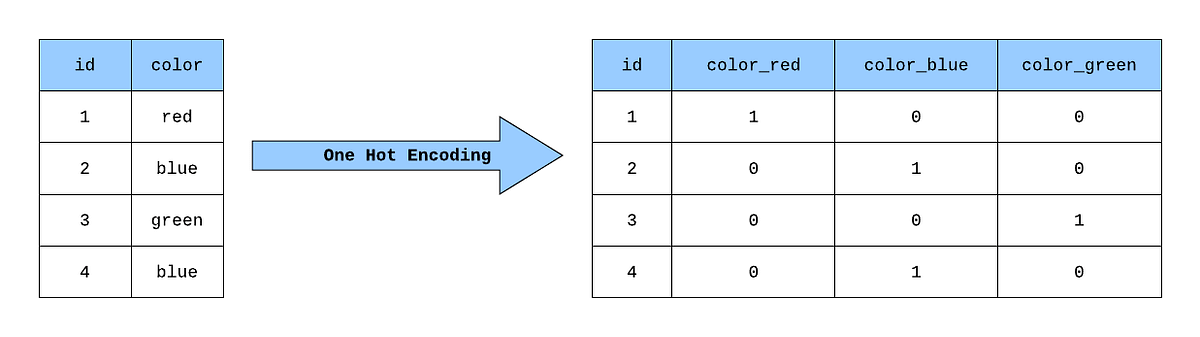

In [12]:
housing_onehot = pd.get_dummies(housing_cat)
housing_onehot

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
14196,False,False,False,False,True
8267,False,False,False,False,True
17445,False,False,False,False,True
14265,False,False,False,False,True
2271,False,True,False,False,False
...,...,...,...,...,...
11284,True,False,False,False,False
11964,False,True,False,False,False
5390,True,False,False,False,False
860,True,False,False,False,False
